# Slonczewski STT Extension

Example taken from the Mumax3 paper

Vansteenkiste, Arne, et al. "The design and verification of MuMax3." AIP advances 4.10 (2014).


The team compared the results of Mumax3 with the results from oommf of a 160nm x 80nm x 5nm permalloy film. Non-zero epislon prime is used.

Implemented by Jed Cheng (jed.cheng@mag.ed.kyushu-u.ac.jp)

In [1]:
# !pip install -q magnumnp numpy==1.22.4

In [2]:
from magnumnp import *
import torch
import math



import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

import numpy as np

# Timer.enable()


precision = torch.float32
torch.set_default_dtype(precision)



2024-02-02 12:21:15  magnum.np:INFO magnum.np 1.1.4


In [3]:
!rm -rf data

In [4]:
from magnumnp.common import *
from magnumnp.field_terms import *
from magnumnp.solvers import *
from magnumnp.loggers import *
from magnumnp.utils import *

In [5]:
# initialize state
lx = 160e-9  # x dimension of the sample(m)
ly = 80e-9  # y dimension of the sample (m)
lz = 5e-9  # sample thickness (m)
dx = (2.5e-9, 2.5e-9, 5e-9)
n = (int(lx/dx[0]), int(ly/dx[1]), int(lz/dx[2]))
mesh = Mesh(n, dx)


In [6]:


state = State(mesh)
state.material = {
    "Ms": 8e5,
    "A": 1.3e-11,
    "alpha": 0.01,
    "P": 0.5669,
    "Lambda": 2,
    "gamma0": 2.211e5,
    "epsilon_prime": 1,
    "p": state.Tensor((math.cos(math.radians(20)), 
                       math.sin(math.radians(20)), 0)),
    "d": lz,
    "J": -4e11,
    }


state.m = state.Constant([0,0,0])
state.m[:,:,:, 0] = 1.

state.Slonczewski = True # enable slonczewski spin torque

# initialize field terms
demag    = DemagField()
exchange = ExchangeField()
torque  = SpinTorqueSlonczewski(state)

Timer.enable()

# perform integration with spin torque
llg = LLGSolver([demag, exchange, torque])
logger = Logger("data", ['t', 'm'], ["m"])
while state.t < 0.5e-9:
    llg.step(state, 5e-12)
    logger << state

Timer.print_report()




2024-02-02 12:21:15  magnum.np:INFO [State] running on device: cuda:0 (dtype = float32)
2024-02-02 12:21:15  magnum.np:INFO [Mesh] 64x32x1 (size= 2.5e-09 x 2.5e-09 x 5e-09)
2024-02-02 12:21:16  magnum.np:INFO [LLGSolver] using RKF45 solver (atol = 1e-05)
2024-02-02 12:21:16  magnum.np:INFO [DEMAG]: Time calculation of demag kernel = 0.15580463409423828 s
2024-02-02 12:21:19  magnum.np:INFO [LLG] step: dt= 5e-12  t=5e-12
2024-02-02 12:21:19  magnum.np:INFO [LLG] step: dt= 5e-12  t=1e-11
2024-02-02 12:21:20  magnum.np:INFO [LLG] step: dt= 5e-12  t=1.5e-11
2024-02-02 12:21:20  magnum.np:INFO [LLG] step: dt= 5e-12  t=2e-11
2024-02-02 12:21:20  magnum.np:INFO [LLG] step: dt= 5e-12  t=2.5e-11
2024-02-02 12:21:20  magnum.np:INFO [LLG] step: dt= 5e-12  t=3e-11
2024-02-02 12:21:20  magnum.np:INFO [LLG] step: dt= 5e-12  t=3.5e-11
2024-02-02 12:21:20  magnum.np:INFO [LLG] step: dt= 5e-12  t=4e-11
2024-02-02 12:21:20  magnum.np:INFO [LLG] step: dt= 5e-12  t=4.5e-11
2024-02-02 12:21:20  magnum.np:I


TIMER REPORT
Operation                      No of calls    Avg time [ms]    Total time [s]
---------------------------  -------------  ---------------  ----------------
LLGSolver.step                         100       119.439            11.9439
    DemagField.h                      8310         0.544051          4.52107
    ExchangeField.h                   8310         0.510661          4.24359
    SpinTorqueSlonczewski.h           8310         0.121719          1.01148
---------------------------  -------------  ---------------  ----------------
Total                                                               12.1992
Missing                                                              0.255272



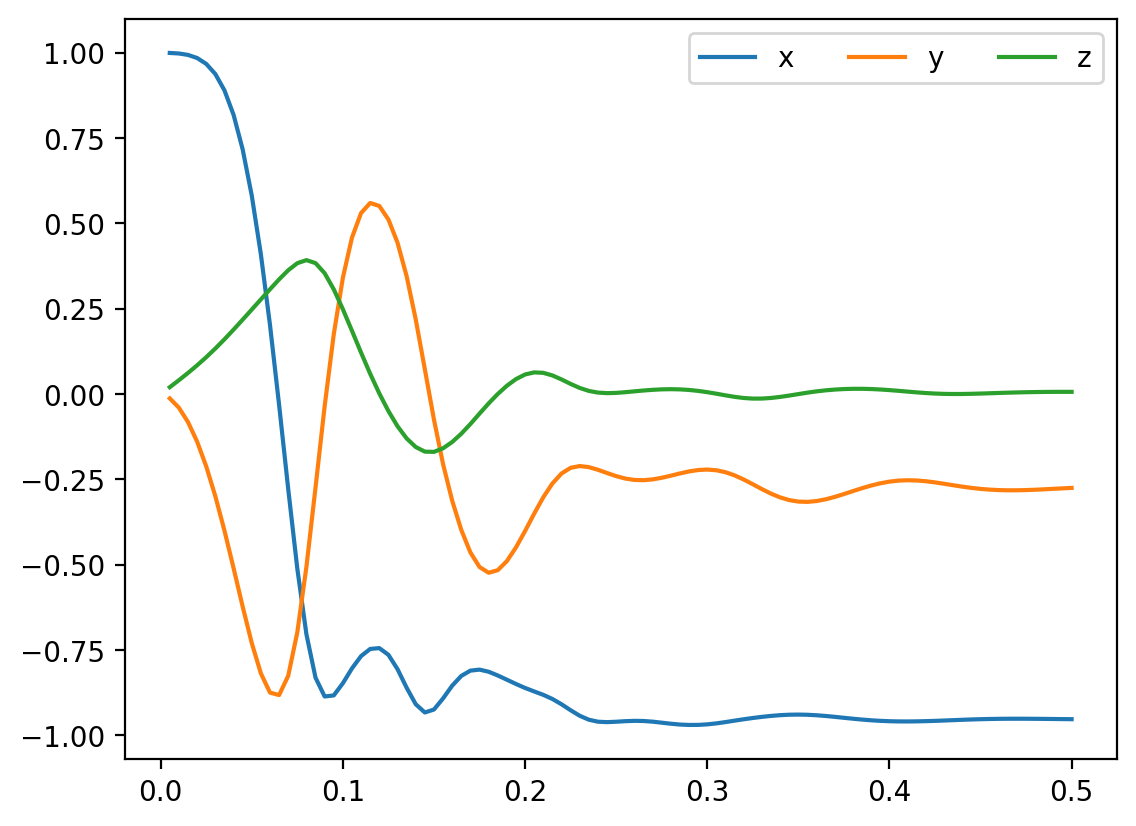

In [7]:
data = np.loadtxt("data/log.dat")

plt.plot(data[:,0]*1e9, data[:,1],  label = "x")
plt.plot(data[:,0]*1e9, data[:,2],  label = "y")
plt.plot(data[:,0]*1e9, data[:,3], label = "z")
plt.legend(ncol=3)
plt.show()

## Plot Results

In [8]:
from os import path
if not path.isdir("ref"):
    !mkdir ref
    !wget -P ref https://gitlab.com/jedcheng/magnum.np/raw/main/demos/slonczewski/ref/M_mx3_1.npy
    !wget -P ref https://gitlab.com/jedcheng/magnum.np/raw/main/demos/slonczewski/ref/M_oommf_1.npy

--2024-02-02 12:21:28--  https://gitlab.com/jedcheng/magnum.np/raw/main/demos/slonczewski/ref/M_mx3_1.npy
Resolving gitlab.com (gitlab.com)... 172.65.251.78, 2606:4700:90:0:f22e:fbec:5bed:a9b9
Connecting to gitlab.com (gitlab.com)|172.65.251.78|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2024-02-02 12:21:28 ERROR 404: Not Found.

--2024-02-02 12:21:29--  https://gitlab.com/jedcheng/magnum.np/raw/main/demos/slonczewski/ref/M_oommf_1.npy
Resolving gitlab.com (gitlab.com)... 172.65.251.78, 2606:4700:90:0:f22e:fbec:5bed:a9b9
Connecting to gitlab.com (gitlab.com)|172.65.251.78|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2024-02-02 12:21:29 ERROR 404: Not Found.



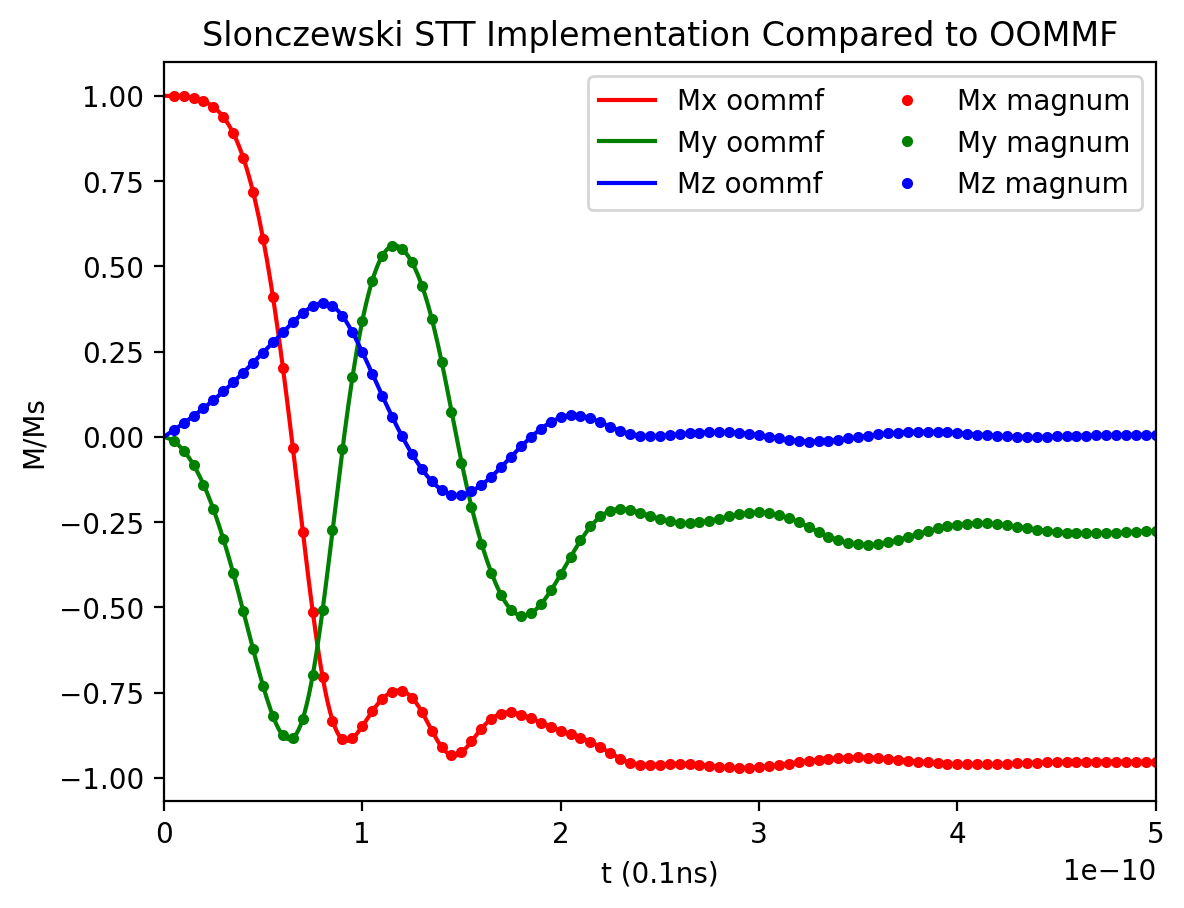

In [10]:
M_mx3 = np.load("ref/M_mx3_1.npy")
M_oommf = np.load("ref/M_oommf_1.npy")

plt.plot(M_oommf[0], M_oommf[1], "r-", label="Mx oommf")
plt.plot(M_oommf[0], M_oommf[2], "g-", label="My oommf")
plt.plot(M_oommf[0], M_oommf[3], "b-", label="Mz oommf")


plt.plot(data[:,0], data[:,1], "r.", label="Mx magnum")
plt.plot(data[:,0], data[:,2], "g.", label="My magnum")
plt.plot(data[:,0], data[:,3], "b.", label="Mz magnum")

plt.legend(ncol=2)
plt.xlim(0, 0.5e-9)
plt.xlabel("t (0.1ns)")
plt.ylabel("M/Ms")
plt.title("Slonczewski STT Implementation Compared to OOMMF")
# plt.savefig("oommf_1.png", dpi=300)
plt.show()

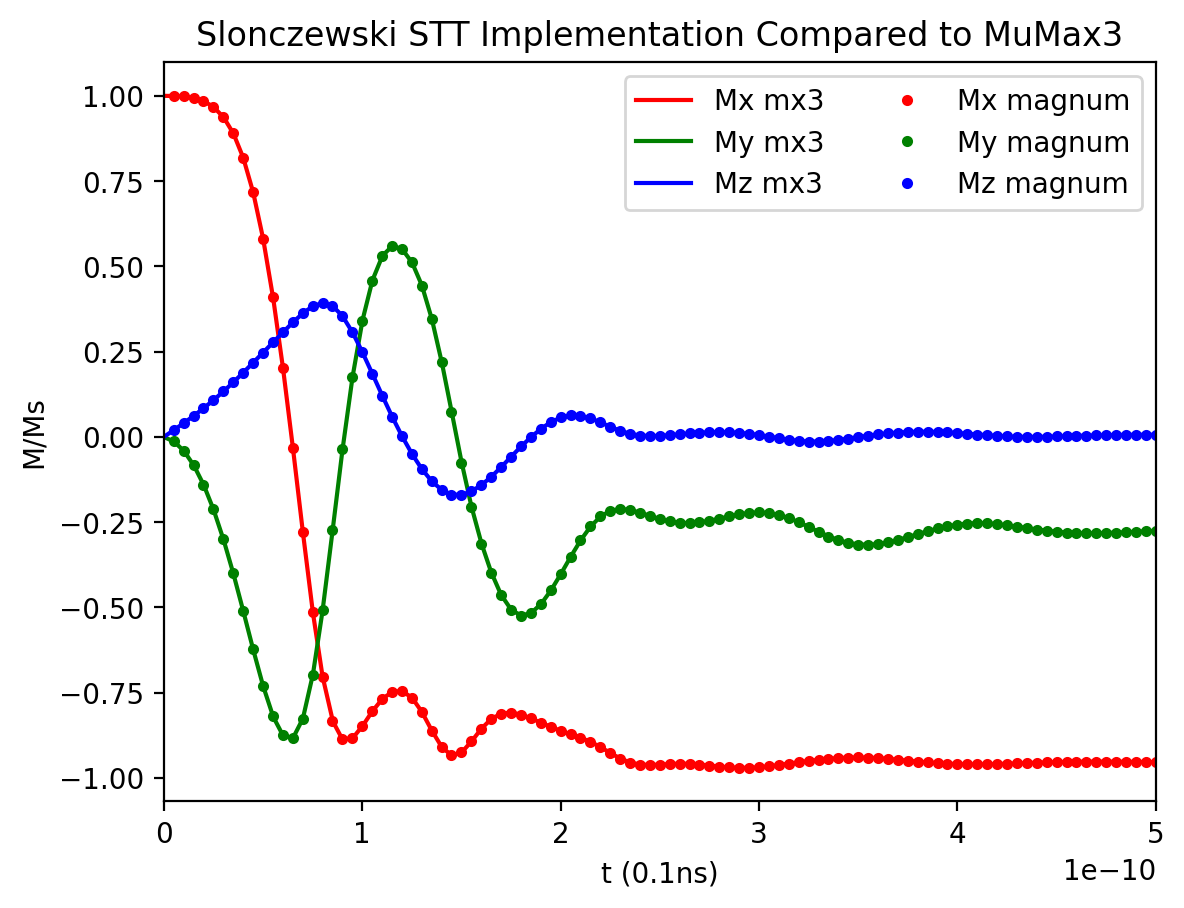

In [11]:
plt.plot(M_mx3[0], M_mx3[1], "r-", label="Mx mx3")
plt.plot(M_mx3[0], M_mx3[2], "g-", label="My mx3")
plt.plot(M_mx3[0], M_mx3[3], "b-", label="Mz mx3")

plt.plot(data[:,0], data[:,1], "r.", label="Mx magnum")
plt.plot(data[:,0], data[:,2], "g.", label="My magnum")
plt.plot(data[:,0], data[:,3], "b.", label="Mz magnum")

plt.legend(ncol=2)
plt.xlim(0, 0.5e-9)
plt.xlabel("t (0.1ns)")
plt.ylabel("M/Ms")
plt.title("Slonczewski STT Implementation Compared to MuMax3")
# plt.savefig("mx3_1.png", dpi=300)
plt.show()